## 1. Exploratory Data Analysis (EDA)

In this section, we perform an initial exploration of the COVID-19 U.S. dataset to understand key patterns, trends, and relationships among variables relevant to pandemic progression and healthcare strain. This helps guide our feature selection and modeling choices for later tasks.

We start by cleaning the dataset, handling missing values using forward-fill interpolation, and removing any remaining gaps in critical columns. Once the data is prepared, we visualize major metrics over time and examine correlations between variables.

Key visualizations include:
- **Daily New Cases** and **New Deaths**: Line plots that reveal major COVID-19 waves and the lag between infections and fatalities.
- **ICU Patients vs. Hospitalizations**: A comparative plot showing how ICU demand tracks overall hospital burden.
- **Correlation Heatmap**: Highlights relationships between variables such as new cases, hospitalizations, and ICU rates.

These analyses provide insight into how pandemic dynamics evolved over time and help identify strong predictors of hospitalization severity for the classification and regression tasks.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Display settings
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")


In [3]:
# Load the U.S.-only dataset
df = pd.read_csv("owid_covid_data_us_subset.csv")
df.head()

,date,total_cases,new_cases,total_deaths,new_deaths,total_cases_per_million,total_deaths_per_million,icu_patients,hosp_patients,weekly_hosp_admissions,daily_case_change_rate,daily_death_change_rate,hospitalization_rate,icu_rate,case_fatality_rate,7day_avg_new_cases,7day_avg_new_deaths,hospitalization_need,icu_requirement
0,2020-07-21,3853351.0,60012.0,145801.0,932.0,11390.679,430.994,11458.0,42195.0,30552.0,NaN,NaN,1.095021,0.297352,3.783746,NaN,NaN,High,High
1,2020-07-22,3911870.0,58519.0,146668.0,867.0,11563.663,433.557,12487.0,46107.0,31352.0,1.518652,0.594646,1.178643,0.319208,3.749307,NaN,NaN,High,High
2,2020-07-23,3975206.0,63336.0,147861.0,1193.0,11750.887,437.084,13916.0,47834.0,31679.0,1.619072,0.813402,1.203309,0.350070,3.719581,NaN,NaN,High,High
3,2020-07-24,4047622.0,72416.0,149052.0,1191.0,11964.952,440.604,13627.0,46748.0,31870.0,1.821692,0.805486,1.154950,0.336667,3.682458,NaN,NaN,High,High
4,2020-07-25,4120764.0,73142.0,150306.0,1254.0,12181.163,444.311,14402.0,51831.0,32804.0,1.807036,0.841317,1.257801,0.349498,3.647527,NaN,NaN,High,High


### Cleaning Up The Data

In [10]:
# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])

# Check for missing values
missing = df.isnull().sum().sort_values(ascending=False)
print("Missing values:\n", missing[missing > 0])

df.dropna(subset=[
    '7day_avg_new_cases',
    '7day_avg_new_deaths',
    'daily_case_change_rate',
    'daily_death_change_rate'
], inplace=True)

df.ffill(inplace=True)


Missing values:
 Series([], dtype: int64)


### Plot of the New Cases Over Time

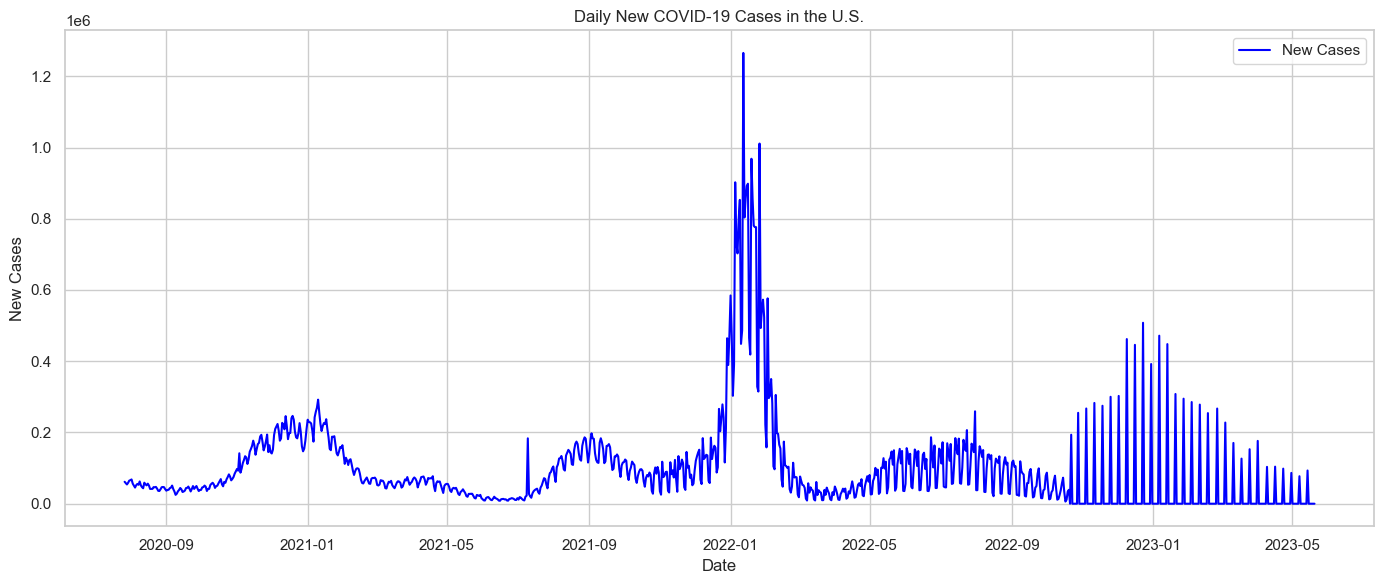

In [11]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=df, x="date", y="new_cases", label="New Cases", color="blue")
plt.title("Daily New COVID-19 Cases in the U.S.")
plt.xlabel("Date")
plt.ylabel("New Cases")
plt.tight_layout()
plt.show()


### Plot of New Deaths Over Time

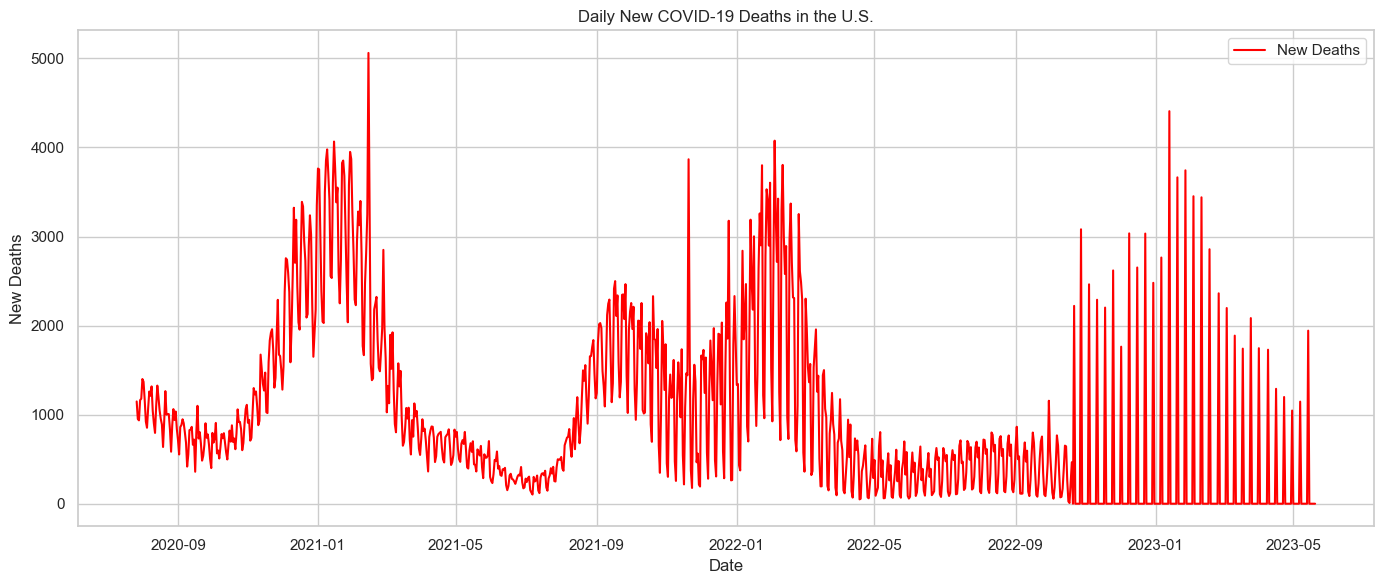

In [12]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=df, x="date", y="new_deaths", label="New Deaths", color="red")
plt.title("Daily New COVID-19 Deaths in the U.S.")
plt.xlabel("Date")
plt.ylabel("New Deaths")
plt.tight_layout()
plt.show()


### ICU vs Hospitalized Patients

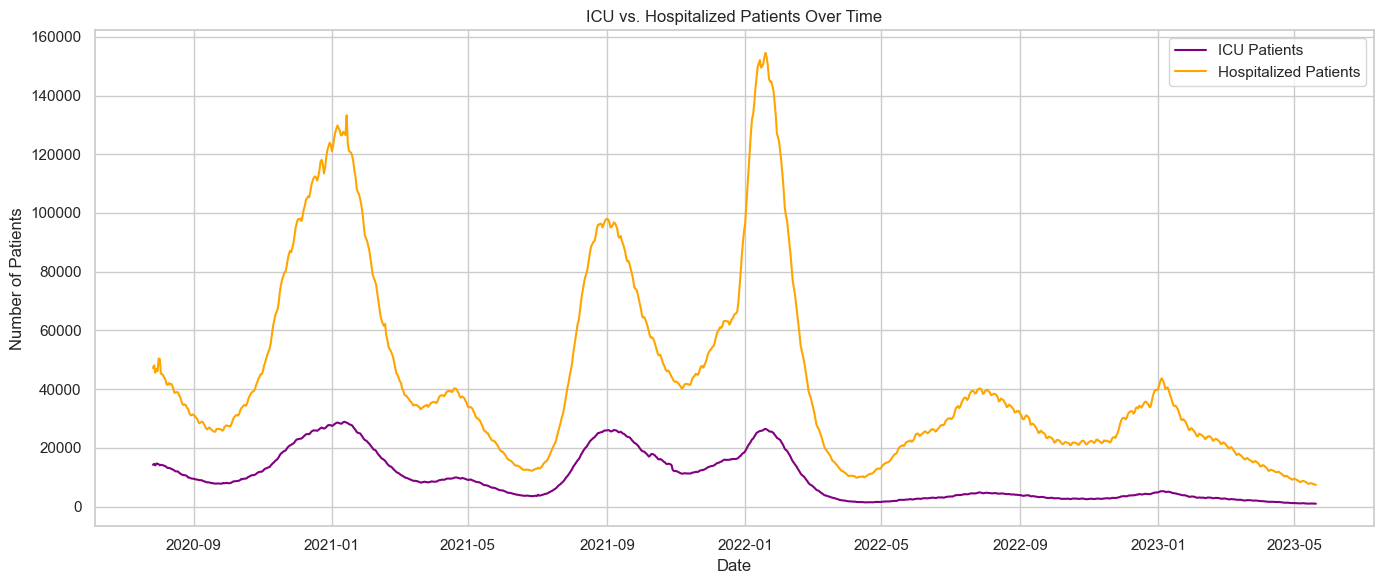

In [13]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=df, x="date", y="icu_patients", label="ICU Patients", color="purple")
sns.lineplot(data=df, x="date", y="hosp_patients", label="Hospitalized Patients", color="orange")
plt.title("ICU vs. Hospitalized Patients Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Patients")
plt.legend()
plt.tight_layout()
plt.show()


### The Correlation Heatmap

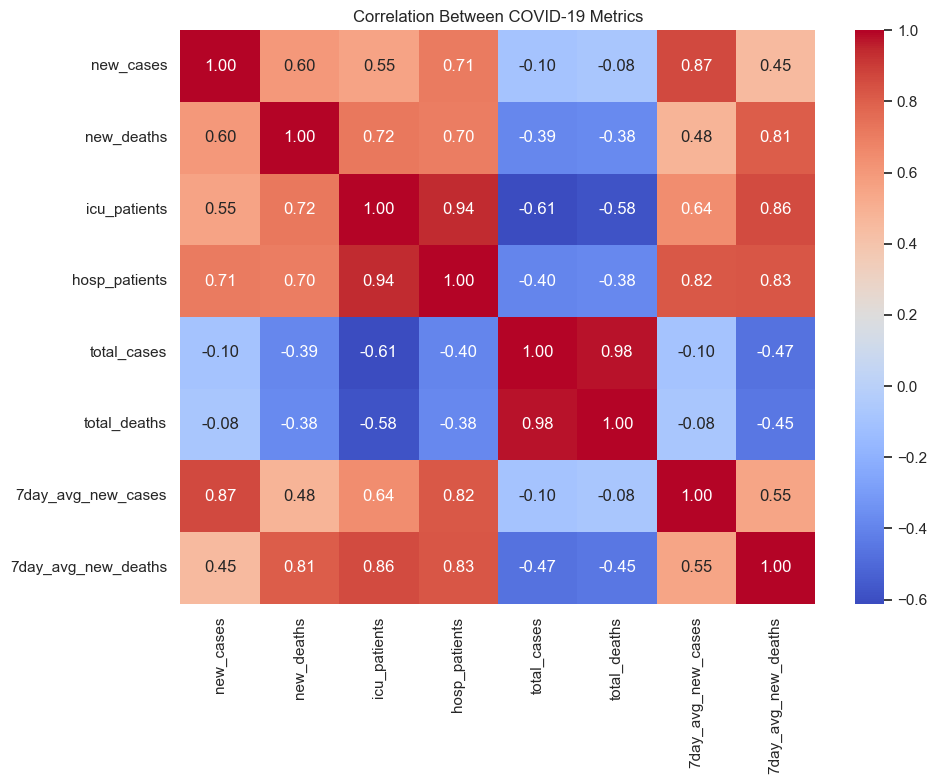

In [14]:
corr_features = [
    'new_cases', 'new_deaths', 'icu_patients',
    'hosp_patients', 'total_cases', 'total_deaths',
    '7day_avg_new_cases', '7day_avg_new_deaths'
]

plt.figure(figsize=(10, 8))
sns.heatmap(df[corr_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Between COVID-19 Metrics")
plt.tight_layout()
plt.show()
